In [1]:
%run constants.py

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [2]:
pwd

"/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989"

In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [4]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND5/load_band5_data.py"

band = Band 5
max_str = 'J163135.750-240128.700'
StokesI_wcs CRPIX = [513. 513.]
StokesI_wcs CDELT = [-5.e-06  5.e-06]
Pixel scale = 0.018 arcsec/pixel
Dec_max_pix = 581
 


In [46]:
path = band5_data_folder_path
path

"/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND5/"

In [5]:
# StokesI_header

GetInfoFromHeader(StokesI_header)


The date is 2022-08-10T00:20:34.512000
The frequency is 203 GHz

The wavelength is 1.5 mm
Pixel scale: 0.018" per pixel

Beam: 0.33" x 0.27" (PA = -88.9°)


In [6]:
# raise SystemExit("Stop here")

In [7]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/CARTA FILES/BAND5/load_carta_data_band5.py"

/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/CARTA FILES/BAND5/load_carta_data_band5.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  carta_major_df_StokesI = pd.read_csv(carta_image_path_band5 + "IRS63_StokesI_CARTA_MAJOR_AXIS_BAND5_18_nterms1_redo.csv",
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/CARTA FILES/BAND5/load_carta_data_band5.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  carta_minor_df_StokesI = pd.read_csv(carta_image_path_band5 + "IRS63_StokesI_CARTA_MINOR_AXIS_BAND5_18_nterms1_redo.csv",
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/CARTA FILES/BAND5/load_carta_data_band5.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version

In [8]:
reccomended_step_count(StokesI_header) 

Recommended sampling step: every 8 pixels


In [9]:
vector_lw = 2

# Stokes I and Polarized Intensity Plot with Vectors

change POLI error?

debias (2.5-9), above 9 do simple one 

galaxy contamination 

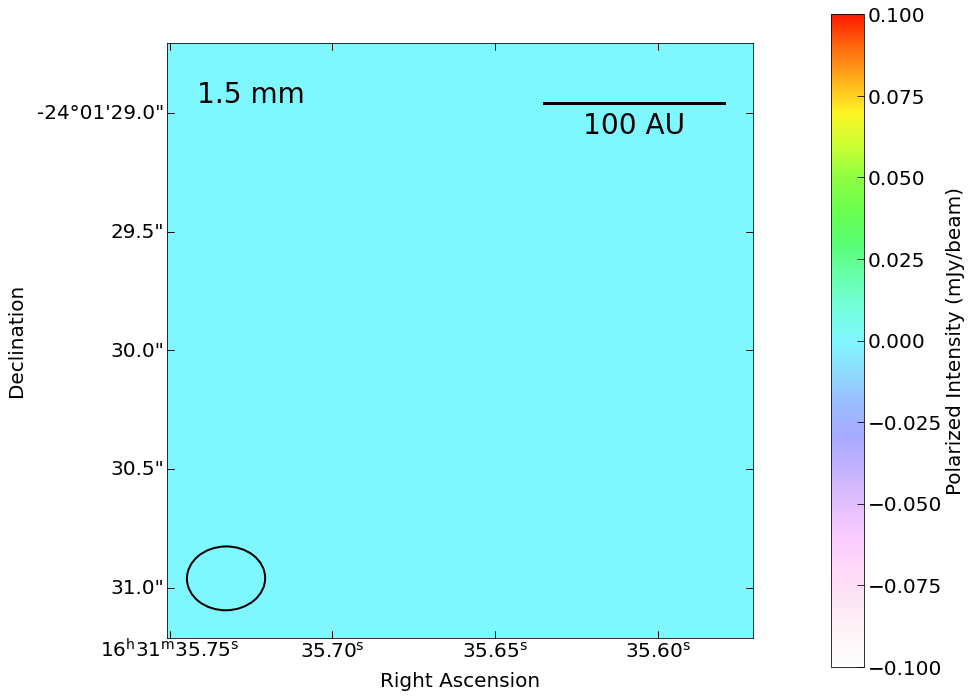

In [10]:
loc = band5_data_folder_path 
POLI_err_file        = loc + "POLI_err_mJy_BAND5.fits"
_, _, POLI_err_mJy_file, _ = read_in_file(POLI_err_file, dimensions = 2)


POLI_diff = np.abs(POLI_err_mJy_file - POLI_err_mJy)


fig, ax = create_base_plot('Band 4 nterms2', StokesI_wcs, POLI_diff, 'Polarized Intensity (mJy/beam)', soft_colormap_v2, 
                           xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                           BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                           max_length_pix, reference_fraction, label = 'wavelength')

In [11]:
print("file err min/med/max:",
      np.nanmin(POLI_err_mJy_file),
      np.nanmedian(POLI_err_mJy_file),
      np.nanmax(POLI_err_mJy_file))

print("current err min/med/max:",
      np.nanmin(POLI_err_mJy),
      np.nanmedian(POLI_err_mJy),
      np.nanmax(POLI_err_mJy))

print("diff min/med/max:",
      np.nanmin(POLI_diff),
      np.nanmedian(POLI_diff),
      np.nanmax(POLI_diff))

file err min/med/max: 0.013699998446368773 0.013700000001242432 0.013700001522608264
current err min/med/max: 0.013699998446368773 0.013700000001242432 0.013700001522608264
diff min/med/max: 0.0 0.0 0.0


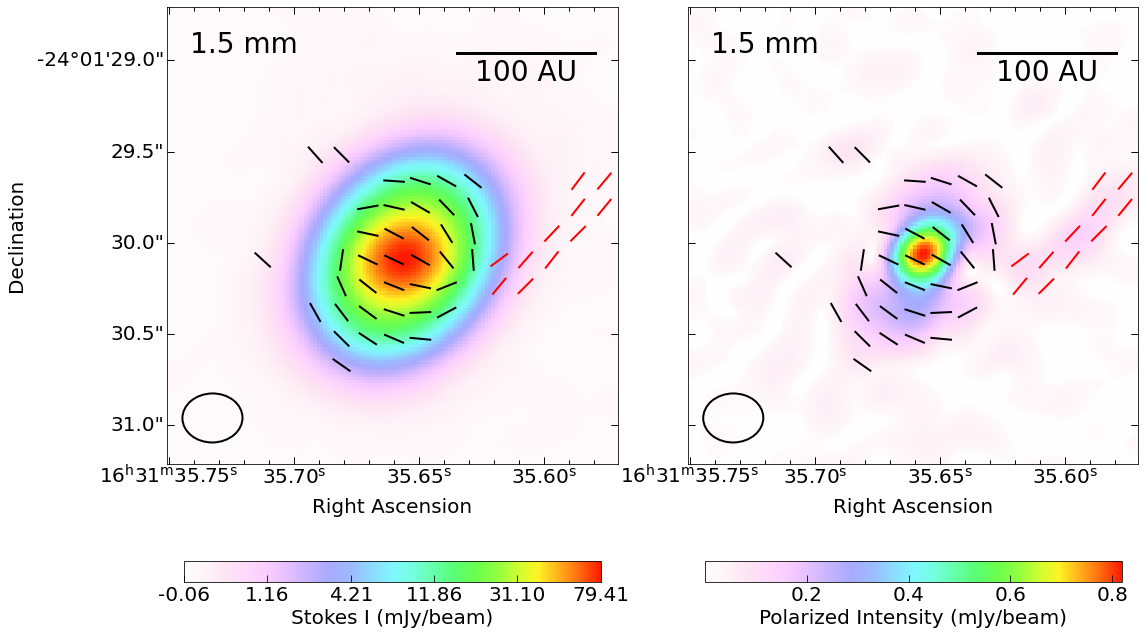

In [12]:
fig, ax = create_stokes_i_plus_one_base_plot('Band 5', StokesI_wcs, StokesI_stretched_mJy, 
                                             normalized_cbar_ticks, StokesI_unstretched_cbar_ticks, 
                                             POLI_debiased_mJy, 'Polarized Intensity (mJy/beam)',
                                             soft_colormap_v2, 
                                             xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                                             BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                                             max_length_pix, reference_fraction, label = 'wavelength')

for i in range(2):
    for row in vector_data_actual_cartesian:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='black', lw = vector_lw)
    
    for row in stream_vectors:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='red', lw = vector_lw)
    

# ax[0].axvline(510, color = 'red')
# ax[0].axvline(520, color = 'blue')
# ax[0].axhline(580, color = 'green')
# ax[0].axhline(520, color = 'orange')

plt.savefig(writeup_image_folder_path + '/StokesI_POLI/'+ "IRS63_StokesI_POLI_vectors_BAND5.pdf", 
            dpi=300, 
            bbox_inches='tight')    
 

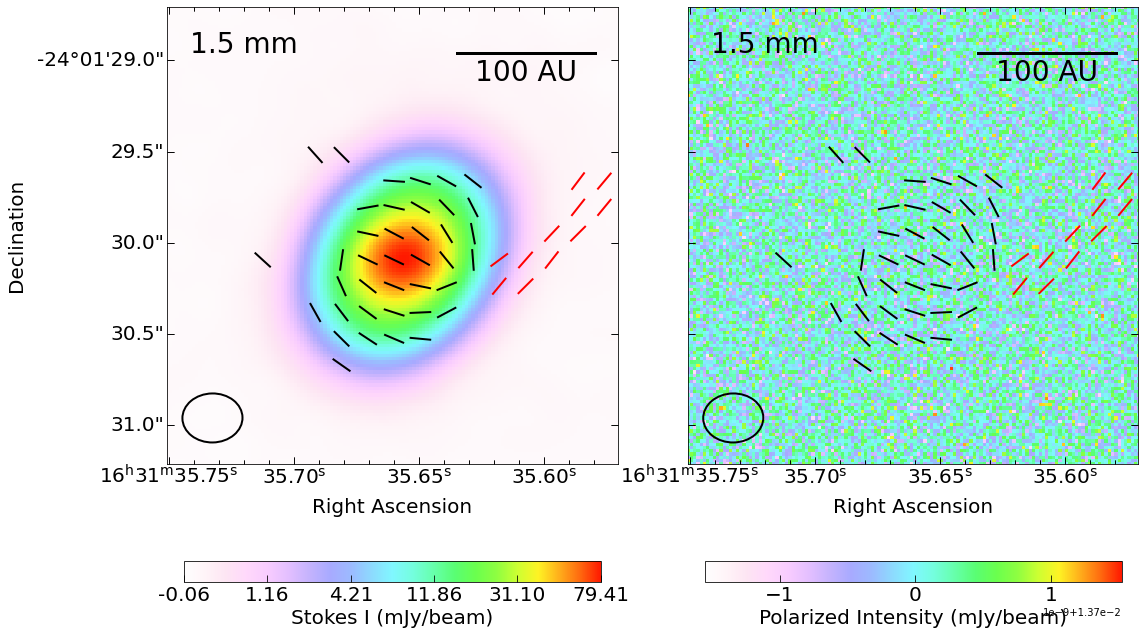

In [13]:
fig, ax = create_stokes_i_plus_one_base_plot('Band 5', StokesI_wcs, StokesI_stretched_mJy, 
                                             normalized_cbar_ticks, StokesI_unstretched_cbar_ticks, 
                                             POLI_err_mJy, 'Polarized Intensity (mJy/beam)',
                                             soft_colormap_v2, 
                                             xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                                             BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                                             max_length_pix, reference_fraction, label = 'wavelength')

for i in range(2):
    for row in vector_data_actual_cartesian:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='black', lw = vector_lw)
    
    for row in stream_vectors:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='red', lw = vector_lw)
    

# ax[0].axvline(510, color = 'red')
# ax[0].axvline(520, color = 'blue')
# ax[0].axhline(580, color = 'green')
# ax[0].axhline(520, color = 'orange')

# plt.savefig(writeup_image_folder_path + '/StokesI_POLI/'+ "IRS63_StokesI_POLI_vectors_BAND5.pdf", 
#             dpi=300, 
#             bbox_inches='tight')    
 

In [14]:
# raise SystemExit("Stop here")

In [15]:
# fig, ax = create_stokes_i_base_plot('Band 5', 
#                                     StokesI_wcs, StokesI_stretched_mJy, 
#                                     soft_colormap_v2, 
#                               normalized_cbar_ticks, StokesI_unstretched_cbar_ticks, 
#                               xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
#                               BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
#                               max_length_pix, reference_fraction, label = 'wavelength',
#                             text_fs = 50, 
#                               axis_labels = False,
#                               x_label = False,
#                               y_label = False,
#                               x_num = False,
#                               y_num = False,
#                               full_axis_labels = False,
#                              cbar_on = False,
#                                     reference_lw = 5,
#                             beam_lw = 4,
#                         spline_lw = 3,
#                                    major_tick_length = 15)


# first_real = True
# for row in vector_data_actual_cartesian:
#     ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5, 
#             label='Polarization' if first_real else None)
    
#     first_real = False

# first_real = True
# for row in stream_vectors:
#     ax.plot([row[0], row[1]], [row[2], row[3]], color='red', lw = 5, 
#                   label='Streamer' if first_real else None)
        
#     first_real = False
    
    
    
    

# ax.legend(fontsize = 34,
#          loc = 'lower right')


# plt.savefig(poster_image_folder_path + "IRS63_StokesI_BAND5_poster.png", 
#             dpi=300, 
#             transparent=True)  

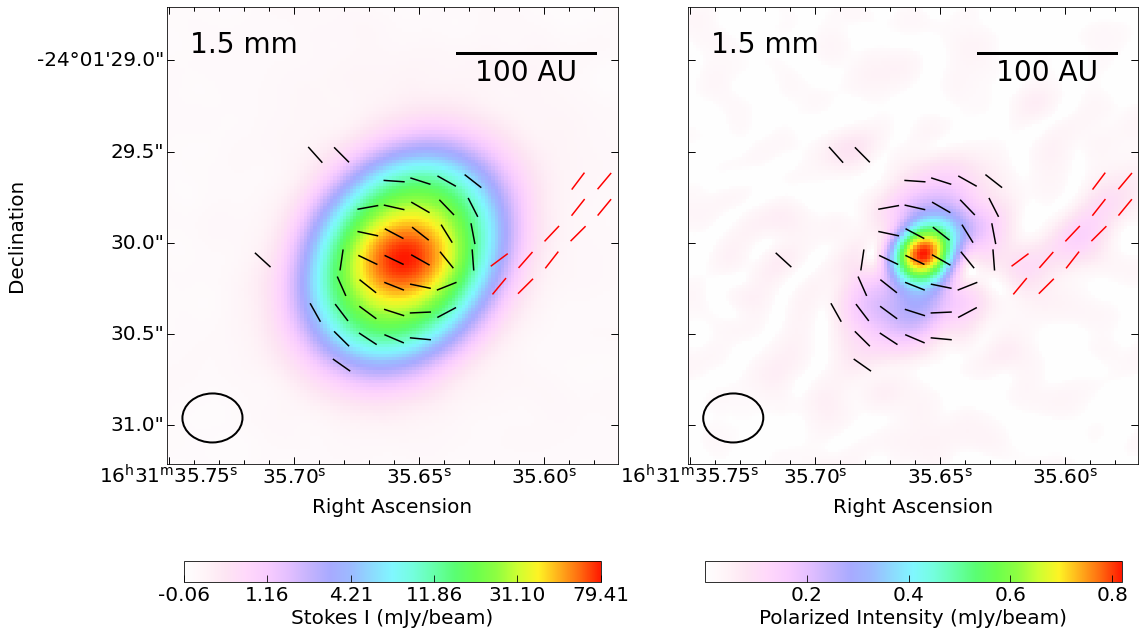

In [16]:
fig, ax = create_stokes_i_plus_one_base_plot("Band 5", StokesI_wcs, StokesI_stretched_mJy, 
                                             normalized_cbar_ticks, StokesI_unstretched_cbar_ticks, 
                                             POLI_debiased_mJy, 'Polarized Intensity (mJy/beam)',
                                             soft_colormap_v2, 
                                             xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                                             BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                                             max_length_pix, reference_fraction, label = 'wavelength')


for i in range(2):
    for row in vector_data_actual_cartesian:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='black')
    
    for row in stream_vectors:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='red')
    

# ax[0].axvline(510, color = 'red')
# ax[0].axvline(520, color = 'blue')
# ax[0].axhline(580, color = 'green')
# ax[0].axhline(520, color = 'orange')

plt.savefig(writeup_image_folder_path + '/StokesI_POLI/'+ "IRS63_StokesI_POLI_vectors_BAND5.pdf", 
            dpi=300, 
            bbox_inches='tight')    
 

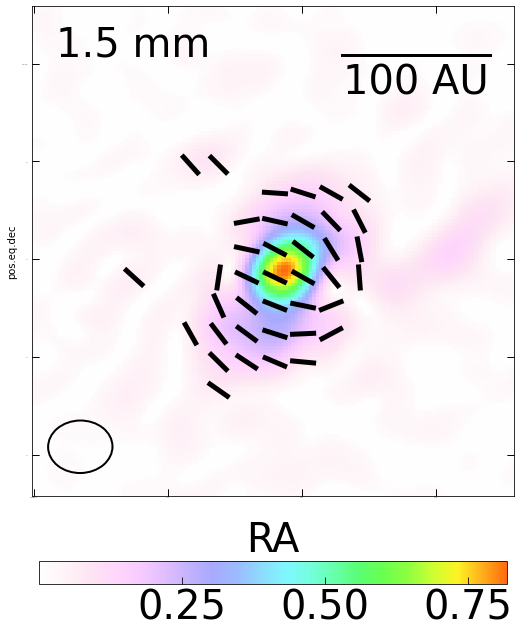

In [17]:
fig, ax = create_base_plot('Band 5', 
                           StokesI_wcs, 
                           POLI_debiased_mJy, 'Polarized Intensity (mJy/beam)', 
                           soft_colormap_no_red, 
                           xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                           BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                           max_length_pix, reference_fraction,
                           label ='wavelength', 
                           plot_for_slides = True)


first_real = True
for row in vector_data_actual_cartesian:
    ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5, 
            label='Real' if first_real else None)
    first_real = False
    


plt.savefig(slideshow_image_folder_path + '/POLI/'+ "IRS63_POLI_BAND5_slides.jpeg", 
            dpi=300, 
            bbox_inches='tight')  

In [18]:
# raise SystemExit("Stop here")

# Slices Along Major and Minor Axes

In [19]:
major_data_StokesI, major_offset_arcsec_StokesI, minor_data_StokesI, minor_offset_arcsec_StokesI, slices_points = run_slices(StokesI_mJy, 
                                                                                                                             StokesI_header,
                                                                                                                             StokesI_wcs,
                                                                                                                             carta_major_data_mJy_StokesI, 
                                                                                                                             carta_minor_data_mJy_StokesI,
                                                                                                                             carta_minor_offset_StokesI,
                                                                                                                             carta_major_offset_StokesI,
                                                                                                                             'Band 5',
                                                                                                                             print_statement = False)

In [20]:
major_data_POLI, major_offset_arcsec_POLI, minor_data_POLI, minor_offset_arcsec_POLI, _ = run_slices(POLI_debiased_mJy, 
                                                                                                     StokesI_header,
                                                                                                     StokesI_wcs, 
                                                                                                     carta_major_data_mJy_POLI,
                                                                                                     carta_minor_data_mJy_POLI,
                                                                                                     carta_minor_offset_POLI,
                                                                                                     carta_major_offset_POLI,
                                                                                                     'Band 5',
                                                                                                     print_statement = True)

 
in run_slices
The length of major_x, _y, minor_x, _ is: 99 99 99 99
 
in extract_axis_data
gridsize: (1024, 1024)
length of axis_data: 99
length of offset_pixels: 99
length of offset_arcsec: 99
 
 
in extract_axis_data
gridsize: (1024, 1024)
length of axis_data: 99
length of offset_pixels: 99
length of offset_arcsec: 99
 
The major angle (cartesian) is: 238.8 degrees
The minor angle (cartesian) is: 148.8 degrees
 
Major start: (489.091, 461.236) pixels
Major end:   (540.909, 546.764) pixels
Minor start: (472.236, 529.909) pixels
Minor end:   (557.764, 478.091) pixels
 
RA_centre_pix =  515
Dec_centre_pix =  504


In [21]:
# major_data_POLF, major_offset_arcsec_POLF, minor_data_POLF, minor_offset_arcsec_POLF, _ = run_slices(POLF, 
#                                                                                                      StokesI_header,
#                                                                                                      StokesI_wcs, 
#                                                                                                      carta_major_data_POLF,
#                                                                                                      carta_minor_data_POLF,
#                                                                                                      carta_minor_offset_POLF,
#                                                                                                      carta_major_offset_POLF,
#                                                                                                      'Band 5',
#                                                                                                      print_statement = False)

In [22]:
data_dict = {
    "StokesI_major"         : major_data_StokesI,
    "StokesI_offset_major"  : major_offset_arcsec_StokesI,
    "StokesI_minor"         : minor_data_StokesI,
    "StokesI_offset_minor"  : minor_offset_arcsec_StokesI
}

# Convert to DataFrame
df = pd.DataFrame(data_dict)

# Save to CSV
df.to_csv(band5_carta_folder_path + "IRS63_my_slice_StokesI_BAND5.csv", index=False)

In [23]:
data_dict = {
    "POLI_major"         : major_data_POLI,
    "POLI_offset_major"  : major_offset_arcsec_POLI,
    "POLI_minor"         : minor_data_POLI,
    "POLI_offset_minor"  : minor_offset_arcsec_POLI
}

# Convert to DataFrame
df = pd.DataFrame(data_dict)

# Save to CSV
df.to_csv(band5_carta_folder_path + "IRS63_my_slice_POLI_BAND5.csv", index=False)

In [24]:
# data_dict = {
#     "POLF_major"         : major_data_POLF,
#     "POLF_offset_major"  : major_offset_arcsec_POLF,
#     "POLF_minor"         : minor_data_POLF,
#     "POLF_offset_minor"  : minor_offset_arcsec_POLF
# }

# # Convert to DataFrame
# df = pd.DataFrame(data_dict)

# # Save to CSV
# df.to_csv(band5_carta_folder_path + "IRS63_my_slice_POLF_BAND5.csv", index=False)

In [25]:
major_x, major_y, minor_x, minor_y = slices_points

np.save(
    os.path.join(band5_data_folder_path, "slice_points.npy"),
    {
        "major_x": major_x,
        "major_y": major_y,
        "minor_x": minor_x,
        "minor_y": minor_y,
    },
)

In [26]:
# raise SystemExit("Stop here")

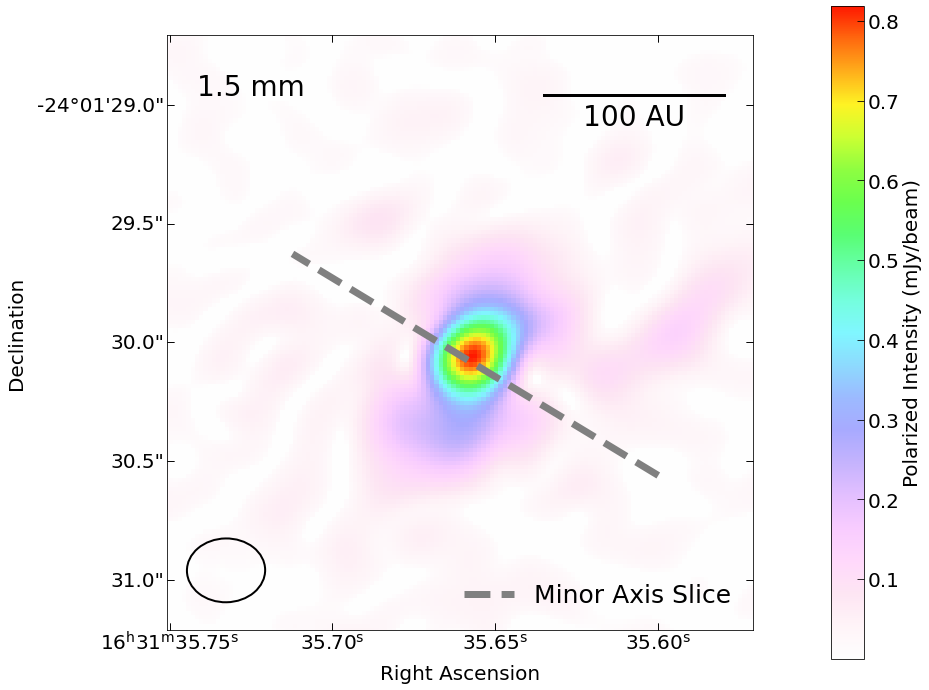

In [27]:
fig, ax = create_base_plot('Band 5', StokesI_wcs, POLI_debiased_mJy, 'Polarized Intensity (mJy/beam)', soft_colormap_v2, 
                           xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                           BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                           max_length_pix, reference_fraction, label = 'wavelength')

# ax.scatter(major_x, 
#            major_y, 
#            label = 'Major Axis Slice',
#            color  = 'blue')

# ax.scatter(minor_x, 
#            minor_y, 
#            label = 'Minor Axis Slice',
#            color = 'red')

# ax.legend(fontsize = legend_text_fs, loc = 'lower right')



MinorAxisSlice(ax, minor_x, minor_y)


plt.savefig(image_folder_path + "WRITEUP/Slices/" + "MinorSlice_BAND5.pdf", 
            dpi=300, 
            bbox_inches='tight')

In [28]:
# raise SystemExit("Stop here")

In [29]:
# fig, ax = create_base_plot(StokesI_wcs, 
#                            POLI_mJy, 'Polarized Intensity (mJy/beam)', 
#                            soft_colormap_no_red, 
#                            xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
#                            BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
#                            max_length_pix, reference_fraction,
#                            cbar_fs = 40,
#                            axis_label_fs = 40,
#                            axis_num_fs = 21,
#                            cbar_orientation = 'horizontal',
#                            cbar_pad = 0.1,
#                            cbar_shrink = 0.9,
#                            fig_size_x = 12,
#                            fig_size_y = 14,
#                            text_fs = 40,
#                            y_label = True, y_num = False,
#                            x_label = True, x_num = False, 
#                            full_axis_labels = False,
#                            cbar_num_fs = 40,
#                            line_y_frac = 0.05)


# # ax.scatter(major_x, 
# #            major_y, 
# #            label = 'Major',
# #            color  = 'blue')

# ax.scatter(minor_x, 
#            minor_y, 
#            label = 'Minor',
#            color = 'red')

# # ax.legend(fontsize = 30, loc = 'upper left')


# plt.savefig(slideshow_image_folder_path + "IRS63_minor_slice_BAND5_slides.jpeg", 
#             dpi=300, 
#             bbox_inches='tight')  


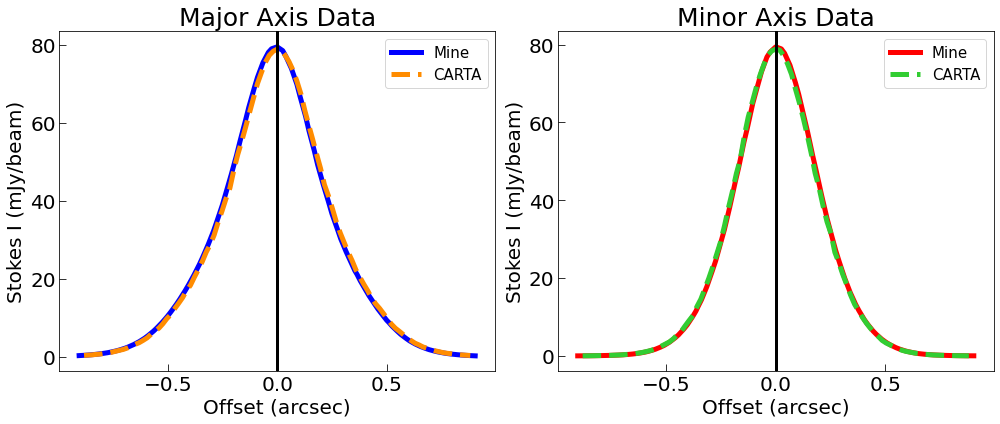

In [30]:
ax = plot_slices_along_axes(
    major_data_StokesI,
    minor_data_StokesI,
    carta_major_data_mJy_StokesI,
    carta_minor_data_mJy_StokesI,
    major_offset_arcsec_StokesI,
    minor_offset_arcsec_StokesI,
    carta_major_offset_StokesI,
    carta_minor_offset_StokesI,
    BMAJ_deg, BMIN_deg, 
    y_label="Stokes I (mJy/beam)",
    type_of_plot="Line",  # or "Scatter",
    cb_friendly = False,
    vline = True,
    fit_slices = True,
    plot_carta = True, 
)

# plt.savefig(image_folder_path + "IRS63_StokesI_slice_BAND5.pdf", 
#             dpi=300, 
#             bbox_inches='tight')

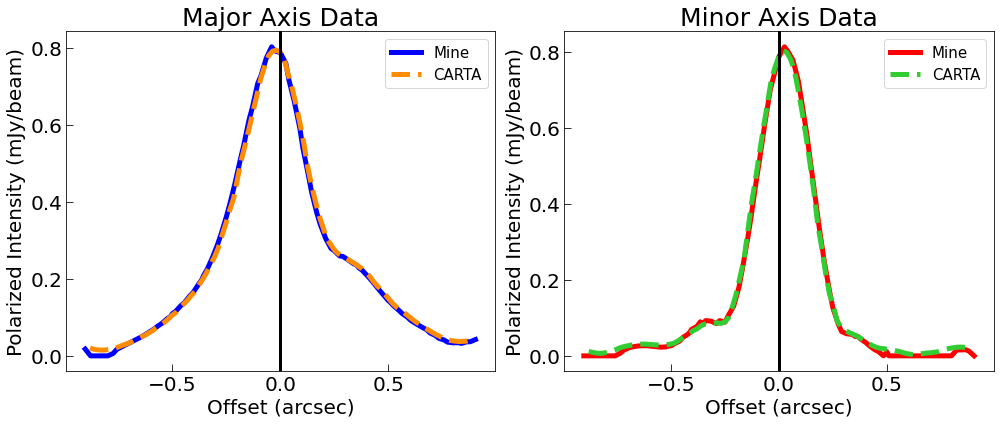

In [31]:
ax = plot_slices_along_axes(
    major_data_POLI,
    minor_data_POLI,
    carta_major_data_mJy_POLI/1000,
    carta_minor_data_mJy_POLI/1000,
    major_offset_arcsec_POLI,
    minor_offset_arcsec_POLI,
    carta_major_offset_POLI,
    carta_minor_offset_POLI,
    BMAJ_deg, BMIN_deg, 
    y_label="Polarized Intensity (mJy/beam)",
    type_of_plot="Line",  # "Line" or "Scatter",
    cb_friendly = False,
    vline = True,
    fit_slices = True,
    plot_carta = True, 
)

# plt.savefig(image_folder_path + "IRS63_POLI_slice_BAND5.pdf", 
#             dpi=300, 
#             bbox_inches='tight')    
 

In [32]:
# ax = plot_slices_along_axes(
#     major_data_POLF,
#     minor_data_POLF,
#     carta_major_data_POLF,
#     carta_minor_data_POLF,
#     major_offset_arcsec_POLF,
#     minor_offset_arcsec_POLF,
#     carta_major_offset_POLF,
#     carta_minor_offset_POLF,
#     BMAJ_deg, BMIN_deg, 
#     y_label="Polarized Fraction",
#     type_of_plot="Line",  # "Line" or "Scatter",
#     cb_friendly = False,
#     vline = True,
#     fit_slices = True
# )

# # plt.savefig(image_folder_path + "IRS63_POLF_slice_BAND5.pdf", 
# #             dpi=300, 
# #             bbox_inches='tight') 
 

In [33]:
# raise SystemExit("Stop here")

# Fitting the slices


$I(r) \propto r^\alpha$

Take log of both sides:
$\log_{10}(I(r))=\alpha \log_{10}(r)+C$

We need to comvert the data from mJy/beam to mJy/arcsec$^2$ (or radians will also work).

We can calculate the beam area with the equation:
$1.113 \cdot BMAJ \cdot BMIN$,
where $BMAJ$ and $BMIN$

# Ratio Models

In [34]:
_, vector_data_plotting_grid, vector_data_list_100U_to_100A, testing_vector_angles = ratio_model(StokesQ_grid_100Uniform, StokesU_grid_100Uniform,
                                                                                                 StokesQ_grid_100Azimuthal, StokesU_grid_100Azimuthal,
                                                                                                 ny, nx,
                                                                                                 vector_length_pix_const,
                                                                                                 StokesI_mJy, StokesI_err_mJy, 
                                                                                                 POLI_mJy_nostream, POLI_err_mJy, 
                                                                                                 PA_err_deg,
                                                                                                 'Band 5',
                                                                                                 # step = 10,
                                                                                                )

All Band 5 using same step


/opt/anaconda3/lib/python3.9/site-packages/IPython/core/events.py:89: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.9/site-packages/IPython/core/events.py:89: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)


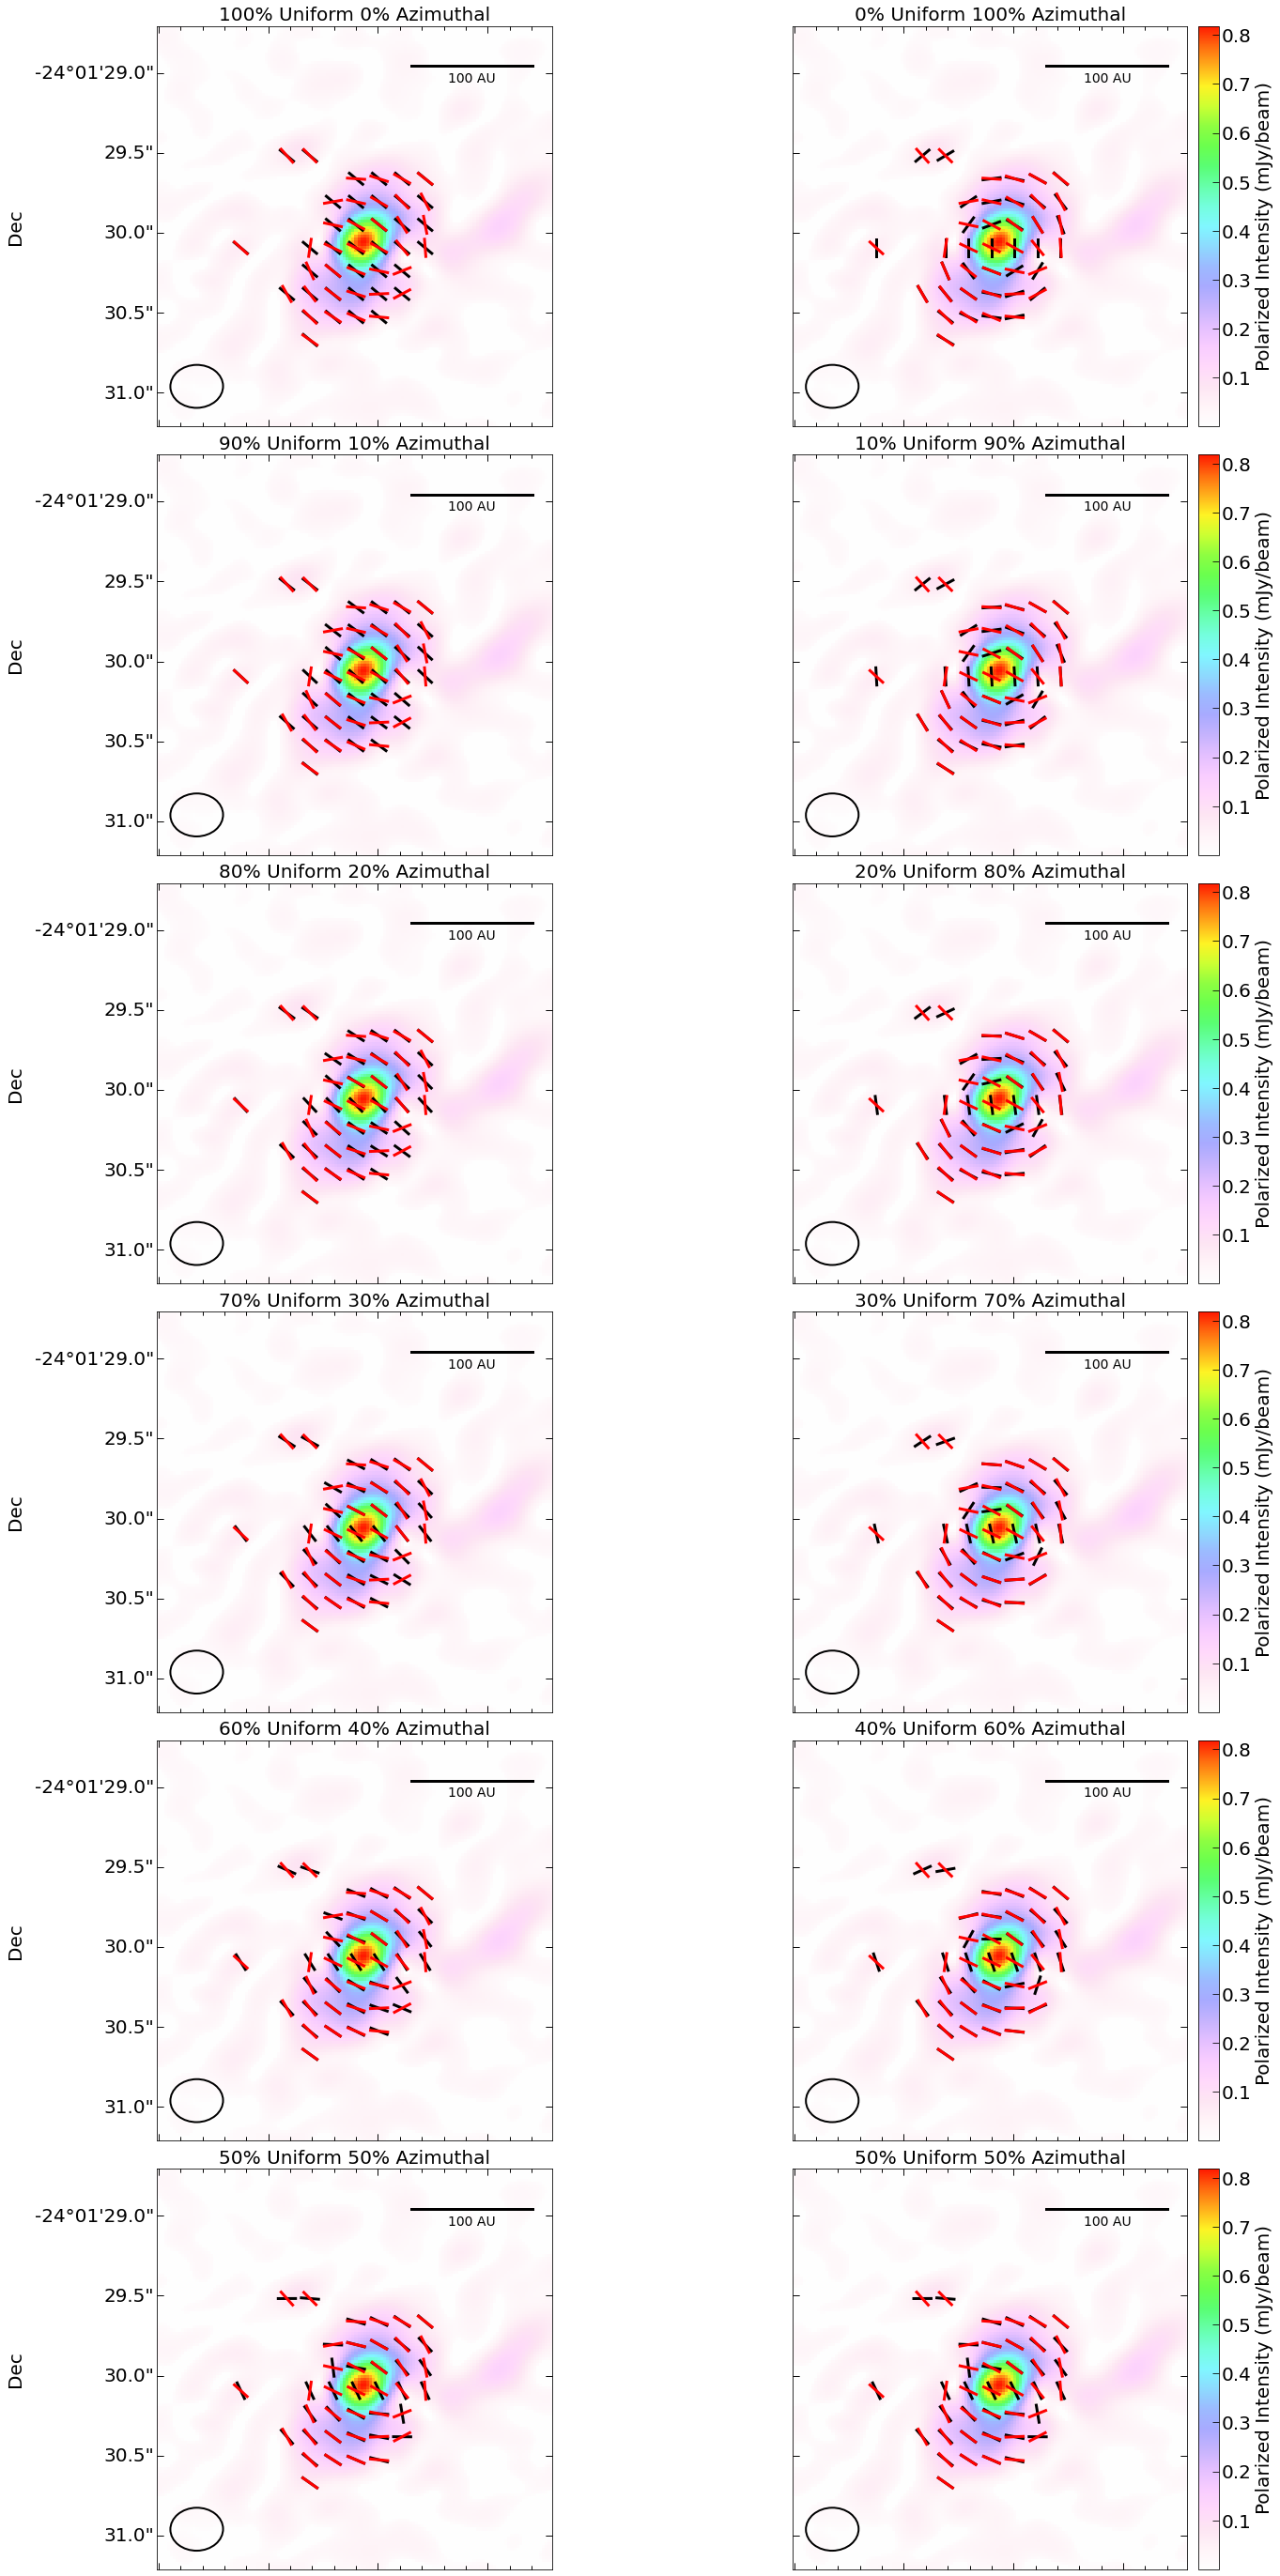

In [35]:
ax = plot_ratio_grid(POLI_debiased_mJy,
                    StokesI_wcs, soft_colormap_v2, 
                    xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                    BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                    max_length_pix, reference_fraction,
                    vector_data_actual_cartesian, vector_data_plotting_grid)

## Find the best one

In [36]:
min_index = find_best_fit_ratio_model(vector_angle_actual_sky, testing_vector_angles, vector_angle_actual_sky_errors)

the length of chi_squared_values is : 11
Chi-squared values for ratio models:
  100 U 0 A: χ² = 0.04
  90 U 10 A: χ² = 0.04
  80 U 20 A: χ² = 0.04
  70 U 30 A: χ² = 0.05
  60 U 40 A: χ² = 0.06
  50 U 50 A: χ² = 0.09
  40 U 60 A: χ² = 0.12
  30 U 70 A: χ² = 0.16
  20 U 80 A: χ² = 0.19
  10 U 90 A: χ² = 0.22
  0 U 100 A: χ² = 0.24

Best-fit ratio model: 100 U 0 A (χ² = 0.04)


In [37]:
# raise SystemExit("Stop here")

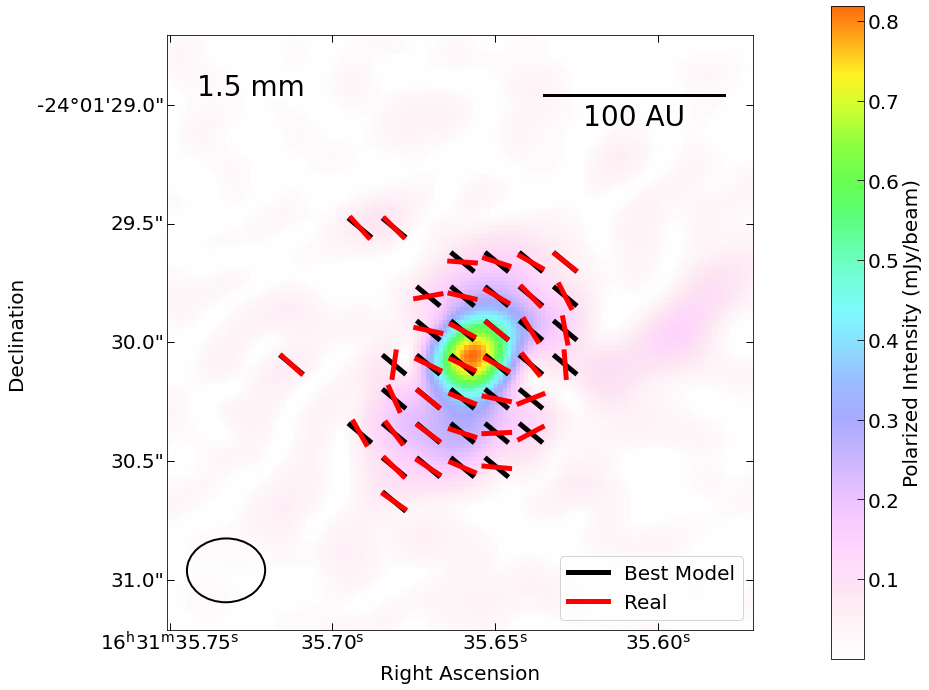

In [38]:
fig, ax = create_base_plot('Band 5', StokesI_wcs, POLI_debiased_mJy, 'Polarized Intensity (mJy/beam)' , 
                           soft_colormap_no_red, 
                           xmin, xmax , ymin, ymax, reference_length_pix, reference_length_AU,
                           BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                           max_length_pix, reference_fraction, label = 'wavelength')

# Add vector plots (Best Model: black)
for i, row in enumerate(vector_data_list_100U_to_100A[min_index]):
    if i == 0:
        ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5, label='Best Model')
    else:
        ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5)

# Plot actual vector data (Real: red)
for i, row in enumerate(vector_data_actual_cartesian):
    if i == 0:
        ax.plot([row[0], row[1]], [row[2], row[3]], color='red', lw=5, label='Real')
    else:
        ax.plot([row[0], row[1]], [row[2], row[3]], color='red', lw=5)

# Show legend
ax.legend(fontsize=legend_title_fs, loc = 'lower right')



plt.savefig(writeup_image_folder_path + '/Ratio/'+ "IRS63_best_ratio_BAND5.pdf", 
            dpi=300, 
            bbox_inches='tight')    

# Gaussian Model 

In [39]:
phi_values = [2, 3, 4, 5, 6, 7]


BMAJ_values_pix =  np.array([10, 20, 30, 40, 50]) # + np.array(BMAJ_pix, dtype=int)
BMIN_values_pix =  np.array([10, 20, 30, 40, 50]) # + np.array(BMIN_pix, dtype=int)

# Print results
print(f'The BMAJ pix values we will test are: {BMAJ_values_pix}')
print(f'The BMIN pix values we will test are: {BMIN_values_pix}')

The BMAJ pix values we will test are: [10 20 30 40 50]
The BMIN pix values we will test are: [10 20 30 40 50]


In [40]:
gaussian_values, gaussian_results, vector_data_gaussian_best, GaussianUniformRatios_best = run_gaussian_model(major_angle_rad_cartesian_band4, phi_values, 
                                                                                                              BMAJ_values_pix, BMIN_values_pix, 
                                                                                                              RA_centre_pix, Dec_centre_pix, 
                                                                                                              StokesQ_grid_100Uniform, StokesU_grid_100Uniform,
                                                                                                              StokesQ_grid_100Azimuthal, StokesU_grid_100Azimuthal,
                                                                                                              vector_angle_actual_sky, vector_angle_actual_sky_errors, 
                                                                                                              ny, nx, 
                                                                                                              StokesI_mJy, StokesI_err_mJy, 
                                                                                                              POLI_mJy_nostream, POLI_err_mJy, 
                                                                                                              PA_err_deg,
                                                                                                              'Band 5',
                                                                                                              print_statements = True)

All Band 5 using same step
The lowest chi-squared value is: χ² = 0.025 when
    phi  = 3.00
    BMAJ = 30.00
    BMIN = 30.00


In [47]:
# path = band4_nterms2_data_folder_path

save_path = os.path.join(
    path,
    "GaussianUniformRatios_best.npy"
)

np.save(save_path, GaussianUniformRatios_best)


save_path = os.path.join(
    path,
    "vector_data_actual_cartesian.npy"
)

np.save(save_path, vector_data_actual_cartesian)


save_path = os.path.join(
    path,
    "vector_data_gaussian_best.npy"
)

np.save(save_path, vector_data_gaussian_best)



save_path = os.path.join(
    path,
    "vector_data_ratio_best.npy"
)

np.save(save_path, vector_data_list_100U_to_100A[min_index])

In [41]:
top5 = sorted(gaussian_values, key=lambda x: x[3])[:5]

top5

[(3, 30, 30, 0.02456545009102982),
 (4, 30, 30, 0.024780953614068485),
 (5, 30, 30, 0.02502901707047751),
 (2, 30, 30, 0.02515379489092895),
 (6, 30, 30, 0.025296548564723617)]

In [42]:
best = top5[0]


# Convert to DataFrame
df = pd.DataFrame([best], columns=["phi", "BMAJ", "BMIN", "chi2"])

# Save
save_path = os.path.join(band5_data_folder_path, "best_gaussian_params.csv")
df.to_csv(save_path, index=False)

df

,phi,BMAJ,BMIN,chi2
0,3,30,30,0.024565


In [43]:
path = band5_data_folder_path


save_path = os.path.join(
    path,
    "GaussianUniformRatios_best.npy"
)

np.save(save_path, GaussianUniformRatios_best)


save_path = os.path.join(
    path,
    "vector_data_actual_cartesian.npy"
)

np.save(save_path, vector_data_actual_cartesian)


save_path = os.path.join(
    path,
    "vector_data_gaussian_best.npy"
)

np.save(save_path, vector_data_gaussian_best)

NameError: name 'labels' is not defined

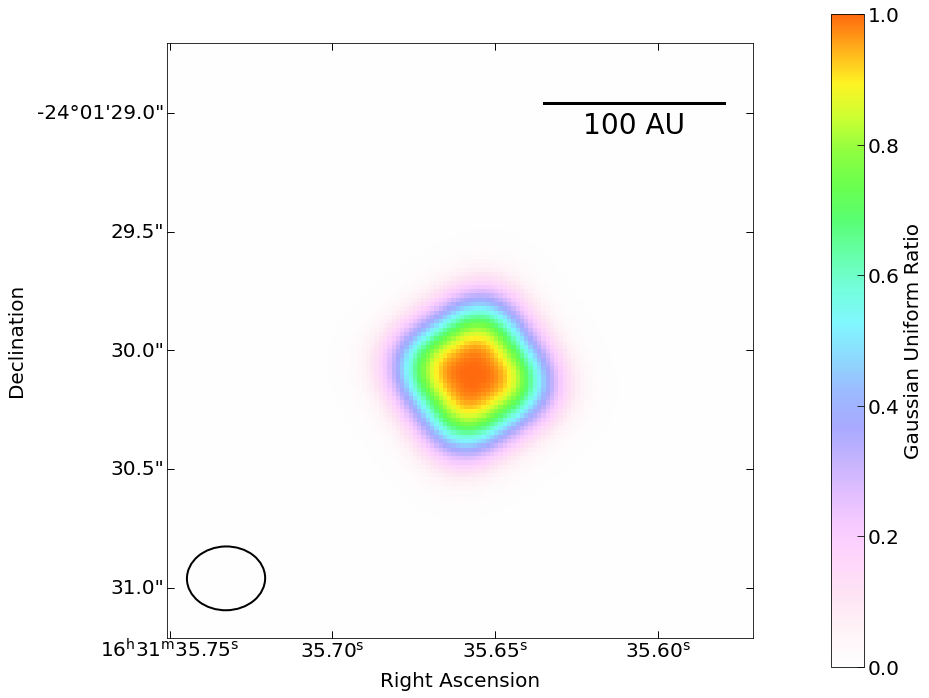

In [44]:
fig, ax = create_base_plot(
    'Band 5',
    StokesI_wcs,
    GaussianUniformRatios_best,
    'Gaussian Uniform Ratio',
    soft_colormap_no_red,
    xmin, xmax, ymin, ymax,
    reference_length_pix, reference_length_AU,
    BMAJ_pix, BMIN_pix, BPA_deg_cartesian,
    max_length_pix, reference_fraction,
)

In [ ]:
fig, ax = create_base_plot('Band 5', StokesI_wcs, 
                           POLI_debiased_mJy, 'Polarized Intensity (mJy/beam)', 
                           soft_colormap_no_red, 
                           xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                           BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                           max_length_pix, reference_fraction, label = 'wavelength')

first_real = True
for row in vector_data_actual_cartesian:
    ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5, 
            label='Real' if first_real else None)
    first_real = False
    
    
# Add vector plots, ensuring the label appears only once
first_best_model = True
for row in vector_data_gaussian_best:
    ax.plot([row[0], row[1]], [row[2], row[3]], color='red', lw=5, 
            label='Best Gaussian Model' if first_best_model else None)
    first_best_model = False

ax.legend(fontsize = legend_text_fs,
         loc = 'lower right')


plt.savefig(writeup_image_folder_path + '/Gaussian/'+ "IRS63_best_gaussian_BAND5.pdf", 
            dpi=300, 
            bbox_inches='tight')  

In [ ]:
# fig, ax = create_base_plot(StokesI_wcs, 
#                            POLI_mJy, 'Polarized Intensity (mJy/beam)', 
#                            soft_colormap_no_red, 
#                            xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
#                            BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
#                            max_length_pix, reference_fraction,
#                            cbar_fs = 40,
#                            axis_label_fs = 40,
#                            axis_num_fs = 21,
#                            cbar_orientation = 'horizontal',
#                            cbar_pad = 0.1,
#                            cbar_shrink = 0.9,
#                            fig_size_x = 12,
#                            fig_size_y = 14,
#                            text_fs = 40,
#                            y_label = True, y_num = False,
#                            x_label = True, x_num = False, 
#                            full_axis_labels = False,
#                            cbar_num_fs = 40,
#                            line_y_frac = 0.05)



# # Plot actual vector data (Real: red)
# for i, row in enumerate(vector_data_actual_cartesian):
#     if i == 0:
#         ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5, label='Real')
#     else:
#         ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5)
        
        
# first_best_model = True
# for row in vector_data_gaussian_best:
#     ax.plot([row[0], row[1]], [row[2], row[3]], color='red', lw=5, 
#             label='Model' if first_best_model else None)
#     first_best_model = False


# # Show legend
# ax.legend(fontsize = 35,
#          loc = 'upper left')

# plt.savefig(slideshow_image_folder_path + "IRS63_best_guassian_BAND5_slides.jpeg", 
#             dpi=300, 
#             bbox_inches='tight')  

## Average POLF when Scattering

In [ ]:
# get_all_POLF_and_save(StokesI_mJy, 
#                       POLI_debiased_mJy, POLF, POLF_err, 
#                       GaussianUniformRatios_best, 
#                       'Band 4 nterms2', 
#                       gaussian_tolerance = 0.001)



get_all_POLF_and_save(StokesI_mJy, 
                      POLI_debiased_mJy, 
                      POLF, POLF_err, 
                      GaussianUniformRatios_best, 'Band 5', gaussian_tolerance = 0.001)

In [ ]:
# from matplotlib.patches import Patch

# # Get boolean mask
# _, mask_POLF = find_gaussian_POLF(GaussianUniformRatios_best, POLF)

# # Create RGBA overlay
# rgba = np.zeros((*mask_POLF.shape, 4))
# rgba[mask_POLF] = [0, 0, 0, 0.6]  # Black with 60% opacity

# # Plot base image
# # fig, ax = simple_plot(StokesI_wcs,
# #                       POLI_debiased_mJy,
# #                       'POLI',
# #                       soft_colormap_v2,
# #                       xmin, xmax, ymin, ymax)

# fig, ax = create_base_plot('Band 4', 
#                            StokesI_wcs, 
#                            POLI_debiased_mJy, 'Polarized Intensity (mJy/beam)', 
#                            soft_colormap_no_red, 
#                            xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
#                            BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
#                            max_length_pix, reference_fraction,
#                            label ='wavelength',
#                            plot_for_slides = True)

# # Overlay mask
# ax.imshow(rgba, origin='lower')

# # ---- Add legend ----
# legend_patch = Patch(facecolor='black', edgecolor='black', alpha=0.6,
#                      label='POLF considered (Uniform Ratio ≈ 1)')

# ax.legend(handles=[legend_patch],
#           loc='lower right',
#           frameon=True,
#           fontsize=16)

# plt.savefig(slideshow_image_folder_path + '/POLF/'+ "Band4.jpeg", 
#             dpi=500, 
#             facecolor='white',
#             bbox_inches='tight')  

## Analyze Gaussian

In [ ]:
# analyze_gaussian_averages_vs_chi2(gaussian_values, phi_values, BMAJ_values_pix, BMIN_values_pix)

In [ ]:
# plot_2d_contours_for_gaussian(gaussian_values, phi_values, BMAJ_values_pix, BMIN_values_pix, 'phi', soft_colormap_v2)

In [ ]:
# plot_2d_contours_for_gaussian(gaussian_values, phi_values, BMAJ_values_pix, BMIN_values_pix, 'BMIN', soft_colormap_v2)

In [ ]:
# plot_2d_contours_for_gaussian(gaussian_values, phi_values, BMAJ_values_pix, BMIN_values_pix, 'BMAJ', soft_colormap_v2)

##### 